# F1 EDA

## 데이터 불러오기 - 대회 제공

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

train.shape, test.shape

((439140, 16), (188165, 15))

In [2]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


In [4]:
submission

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0
...,...,...
188160,627300,0
188161,627301,0
188162,627302,0
188163,627303,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

## 결측값 처리

In [6]:
import numpy as np
import missingno as msno

train.isnull().sum()

test.isnull().sum()
# 결측값이 없음을 확인

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

## 피처 요약표

In [14]:
def resumtable(df):

    print(f'데이터셋 형상 : {df.shape}')

    summary = pd.DataFrame({
        '데이터타입': df.dtypes,
        '고윳값 개수': df.nunique(),
        '결측값 개수': df.isnull().sum()
    })

    summary['데이터 종류'] = None

    for col in df.columns:

        nunique = df[col].nunique()
        dtype = df[col].dtype

        # 이진형
        if nunique == 2:
            summary.loc[col, '데이터 종류'] = '이진형'

        # 문자열/object -> 명목형
        elif dtype == 'object':
            summary.loc[col, '데이터 종류'] = '명목형'

        # 범주 개수 적은 int -> 순서형/범주형 가능
        elif dtype == 'int64':
            if nunique < 20:
                summary.loc[col, '데이터 종류'] = '순서형'
            else:
                summary.loc[col, '데이터 종류'] = '정수형'

        # float -> 연속형
        elif dtype == 'float64':
            summary.loc[col, '데이터 종류'] = '연속형'
        else:
            summary.loc[col, '데이터 종류'] = '기타'

    return summary

summary = resumtable(train)
summary


데이터셋 형상 : (439140, 16)


,데이터타입,고윳값 개수,결측값 개수,데이터 종류
id,int64,439140,0,정수형
Driver,object,887,0,명목형
Compound,object,5,0,명목형
Race,object,26,0,명목형
Year,int64,4,0,순서형
PitStop,int64,2,0,이진형
LapNumber,int64,78,0,정수형
Stint,int64,8,0,순서형
TyreLife,float64,78,0,연속형
Position,int64,20,0,정수형


In [15]:
train['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET'], dtype=object)

## 연속형 피처 히스토그램

In [18]:
summary = resumtable(train)

cont_features = summary[

    summary['데이터 종류'] == '연속형'

].index

데이터셋 형상 : (439140, 16)


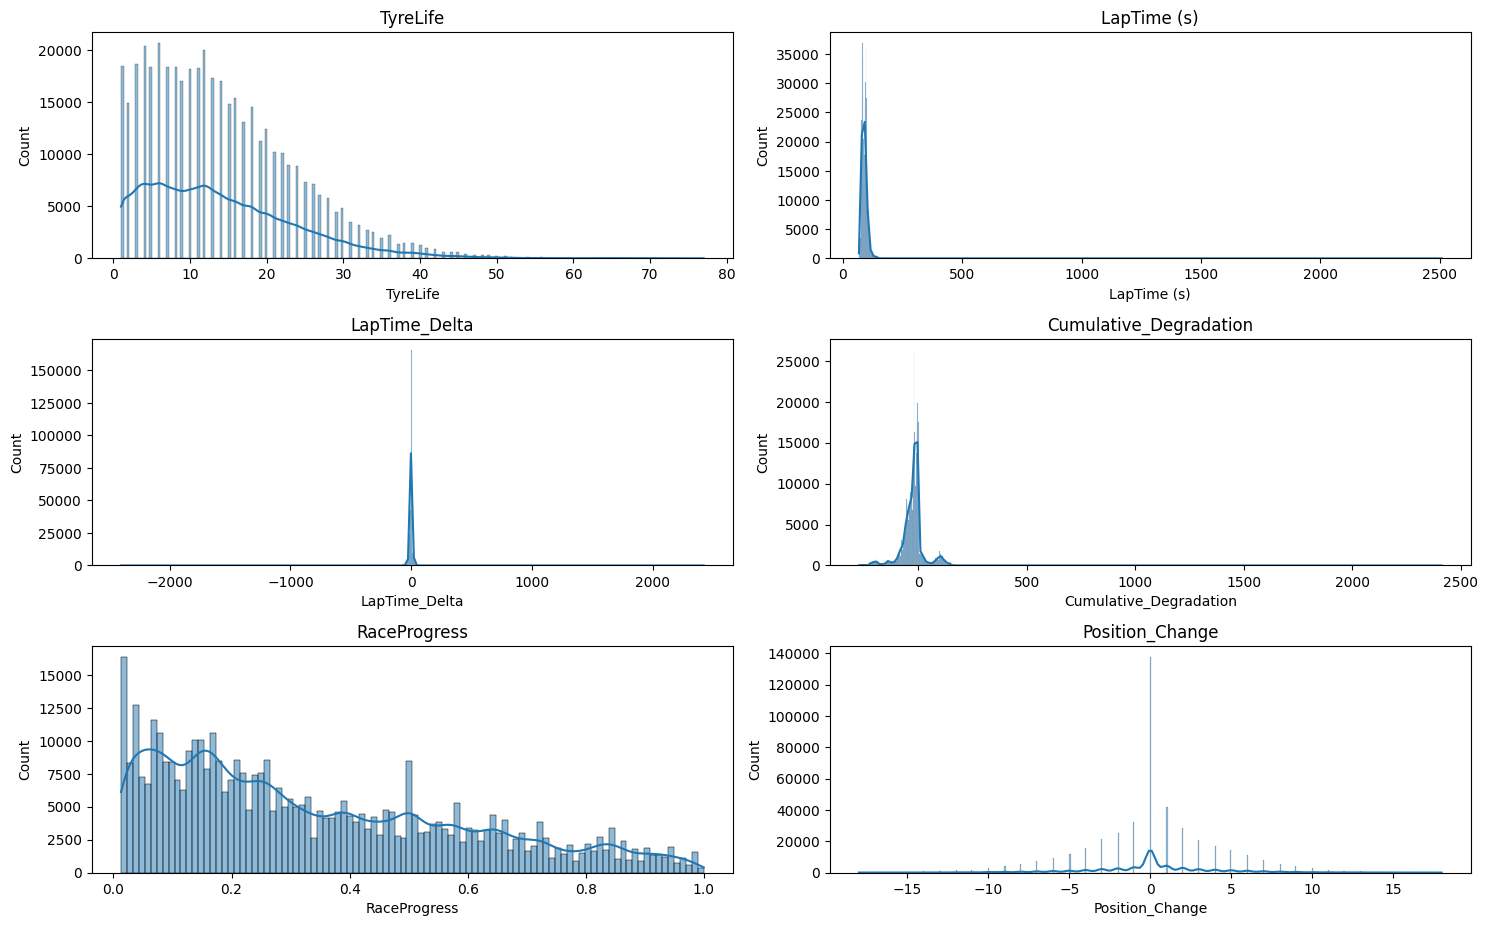

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(df, features, rows, cols, size=(15, 12)):

    fig, axes = plt.subplots(rows, cols, figsize=size)

    axes = axes.flatten()

    for idx, feature in enumerate(features):

        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            ax=axes[idx]
        )

        axes[idx].set_title(feature)

    # 남는 subplot 제거
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

plot_histograms(
    train,
    cont_features,
    rows=4,
    cols=2
)